In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_users = pd.read_csv('Users.csv', encoding='latin-1')
df_books = pd.read_csv('Books.csv', encoding='latin-1')
df_ratings = pd.read_csv('Ratings.csv', encoding='latin-1')
# Loading the datasets

C:\Users\DONGRI ASHMANJUM\AppData\Local\Temp\ipykernel_19344\1647471747.py:2: DtypeWarning: Columns (0: Year-Of-Publication) have mixed types. Specify dtype option on import or set low_memory=False.
  df_books = pd.read_csv('Books.csv', encoding='latin-1')


In [3]:
df_users.head() # Displaying the first few rows of the users dataset 

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [4]:
df_users.describe() # Summary statistics for the users dataset

,User-ID,Age
count,278858.00000,168096.000000
mean,139429.50000,34.751434
std,80499.51502,14.428097
min,1.00000,0.000000
25%,69715.25000,24.000000
50%,139429.50000,32.000000
75%,209143.75000,44.000000
max,278858.00000,244.000000


##### We have some unrealistic values in the Age column, but we havent done any cleaning as of now, because will take care that in the analysis part.

In [5]:
bins = [0,5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 250]
labels = ['0-5', '5-10', '10-20', '20-30', '30-40', '40-50','50-60', '60-70', '70-80', '80-90', '90-100', '100+']

df_users['Age_Group'] = pd.cut(df_users['Age'], bins=bins, labels=labels, include_lowest=True)

# creating the age_group column, which categorizes users into age groups based on their age.

In [6]:
df_users.isnull().sum()

User-ID           0
Location          0
Age          110762
Age_Group    110762
dtype: int64

##### We have so many null values in the Age and Age_group coulumn, which indicates nearly 40%  of the data has null values, using median to replace the null values doesnt make sense. So we are leaving the column as it is

In [7]:
df_users['Location'].str.split(',', expand=True)

,0,1,2,3,4,5,6,7,8
0,nyc,new york,usa,NaN,NaN,NaN,NaN,NaN,NaN
1,stockton,california,usa,NaN,NaN,NaN,NaN,NaN,NaN
2,moscow,yukon territory,russia,NaN,NaN,NaN,NaN,NaN,NaN
3,porto,v.n.gaia,portugal,NaN,NaN,NaN,NaN,NaN,NaN
4,farnborough,hants,united kingdom,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
278853,portland,oregon,usa,NaN,NaN,NaN,NaN,NaN,NaN
278854,tacoma,washington,united kingdom,NaN,NaN,NaN,NaN,NaN,NaN
278855,brampton,ontario,canada,NaN,NaN,NaN,NaN,NaN,NaN
278856,knoxville,tennessee,usa,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df_users['City'] = df_users['Location'].str.split(',').str[0].str.strip()
df_users['State'] = df_users['Location'].str.split(',').str[1].str.strip()
df_users['Country'] = df_users['Location'].str.split(',').str[-1].str.strip()

##### We split the location into city, state and country. After splitting the column location using ',' as delimeter we assign 0 th index to city, 1st index to state, and the last index as country. [ i used -1 to take out the last index value because there are few cases which has more than 2 indexes ]

In [9]:
df_users

,User-ID,Location,Age,Age_Group,City,State,Country
0,1,"nyc, new york, usa",NaN,NaN,nyc,new york,usa
1,2,"stockton, california, usa",18.0,10-20,stockton,california,usa
2,3,"moscow, yukon territory, russia",NaN,NaN,moscow,yukon territory,russia
3,4,"porto, v.n.gaia, portugal",17.0,10-20,porto,v.n.gaia,portugal
4,5,"farnborough, hants, united kingdom",NaN,NaN,farnborough,hants,united kingdom
...,...,...,...,...,...,...,...
278853,278854,"portland, oregon, usa",NaN,NaN,portland,oregon,usa
278854,278855,"tacoma, washington, united kingdom",50.0,40-50,tacoma,washington,united kingdom
278855,278856,"brampton, ontario, canada",NaN,NaN,brampton,ontario,canada
278856,278857,"knoxville, tennessee, usa",NaN,NaN,knoxville,tennessee,usa


In [10]:
df_books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [11]:
print(df_books.iloc[ 0:1, 5:6])

                                         Image-URL-S
0  http://images.amazon.com/images/P/0195153448.0...


In [12]:
df_books.shape

(271360, 8)

In [13]:
df_books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

##### We are not doing any analysis on the books dataset, because it is ready for the analysis, as there are no gaps present, selecting the particular columns will be taken care in the analysis part

In [14]:
df_ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [15]:
df_ratings.duplicated().sum()

np.int64(0)

##### We dont have any duplicate values in the ratings dataset

In [16]:
df_ratings = df_ratings.merge(df_users[['User-ID', 'Age_Group', 'City', 'State','Country']], on='User-ID', how='left')

#### merged the users dataset with ratings dataset 

In [17]:
df_ratings.head()

,User-ID,ISBN,Book-Rating,Age_Group,City,State,Country
0,276725,034545104X,0,NaN,tyler,texas,usa
1,276726,0155061224,5,NaN,seattle,washington,usa
2,276727,0446520802,0,10-20,h,new south wales,australia
3,276729,052165615X,3,10-20,rijeka,n/a,croatia
4,276729,0521795028,6,10-20,rijeka,n/a,croatia


In [18]:
df_ratings.isnull().sum()

User-ID             0
ISBN                0
Book-Rating         0
Age_Group      309492
City                0
State               0
Country             0
dtype: int64

In [19]:
df_ratings = df_ratings.merge(df_books[['ISBN', 'Book-Title', 'Book-Author', 'Image-URL-S']], on='ISBN', how='left')

In [20]:
df_ratings.isnull().sum()

User-ID             0
ISBN                0
Book-Rating         0
Age_Group      309492
City                0
State               0
Country             0
Book-Title     118644
Book-Author    118646
Image-URL-S    118644
dtype: int64

##### merged the books dataset with the updated ratings dataset, Few ISBN Ids are not present in the Books dataset. So we are considering Book-Title as main variable instead of ISBN

In [21]:
df_ratings  

,User-ID,ISBN,Book-Rating,Age_Group,City,State,Country,Book-Title,Book-Author,Image-URL-S
0,276725,034545104X,0,NaN,tyler,texas,usa,Flesh Tones: A Novel,M. J. Rose,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,NaN,seattle,washington,usa,Rites of Passage,Judith Rae,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,10-20,h,new south wales,australia,The Notebook,Nicholas Sparks,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,10-20,rijeka,n/a,croatia,Help!: Level 1,Philip Prowse,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,10-20,rijeka,n/a,croatia,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,http://images.amazon.com/images/P/0521795028.0...
...,...,...,...,...,...,...,...,...,...,...
1149775,276704,1563526298,9,NaN,cedar park,texas,usa,Get Clark Smart : The Ultimate Guide for the S...,Clark Howard,http://images.amazon.com/images/P/1563526298.0...
1149776,276706,0679447156,0,10-20,quebec,quebec,canada,Eight Weeks to Optimum Health: A Proven Progra...,Andrew Weil,http://images.amazon.com/images/P/0679447156.0...
1149777,276709,0515107662,10,30-40,mannington,west virginia,usa,The Sherbrooke Bride (Bride Trilogy (Paperback)),Catherine Coulter,http://images.amazon.com/images/P/0515107662.0...
1149778,276721,0590442449,10,10-20,providence,rhode island,usa,Fourth Grade Rats,Jerry Spinelli,http://images.amazon.com/images/P/0590442449.0...


In [22]:
df_ratings['Book-Title'].nunique()

241071

In [23]:
df_ratings['Age_Group'].value_counts()

Age_Group
30-40     260297
20-30     238086
40-50     159448
50-60      95402
10-20      43119
60-70      30003
100+        3424
5-10        3162
70-80       3104
0-5         2845
90-100       742
80-90        656
Name: count, dtype: int64

In [24]:
df_ratings = df_ratings[(df_ratings['Age_Group'] != '0-5') & (df_ratings['Age_Group'] != '100+')]

##### Removed the unrealistic age groups 

In [25]:
df_ratings['Age_Group'].value_counts() 

Age_Group
30-40     260297
20-30     238086
40-50     159448
50-60      95402
10-20      43119
60-70      30003
5-10        3162
70-80       3104
90-100       742
80-90        656
0-5            0
100+           0
Name: count, dtype: int64

In [26]:
# Remove null titles AND zero ratings
df_filtered = df_ratings[(df_ratings['Book-Title'].notna()) & (df_ratings['Book-Rating'] > 0)]
df_filtered

,User-ID,ISBN,Book-Rating,Age_Group,City,State,Country,Book-Title,Book-Author,Image-URL-S
1,276726,0155061224,5,NaN,seattle,washington,usa,Rites of Passage,Judith Rae,http://images.amazon.com/images/P/0155061224.0...
3,276729,052165615X,3,10-20,rijeka,n/a,croatia,Help!: Level 1,Philip Prowse,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,10-20,rijeka,n/a,croatia,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,http://images.amazon.com/images/P/0521795028.0...
8,276744,038550120X,7,NaN,torrance,california,usa,A Painted House,JOHN GRISHAM,http://images.amazon.com/images/P/038550120X.0...
16,276747,0060517794,9,20-30,iowa city,iowa,usa,Little Altars Everywhere,Rebecca Wells,http://images.amazon.com/images/P/0060517794.0...
...,...,...,...,...,...,...,...,...,...,...
1149771,276704,0743211383,7,NaN,cedar park,texas,usa,Dreamcatcher,Stephen King,http://images.amazon.com/images/P/0743211383.0...
1149773,276704,0806917695,5,NaN,cedar park,texas,usa,Perplexing Lateral Thinking Puzzles: Scholasti...,Paul Sloane,http://images.amazon.com/images/P/0806917695.0...
1149775,276704,1563526298,9,NaN,cedar park,texas,usa,Get Clark Smart : The Ultimate Guide for the S...,Clark Howard,http://images.amazon.com/images/P/1563526298.0...
1149777,276709,0515107662,10,30-40,mannington,west virginia,usa,The Sherbrooke Bride (Bride Trilogy (Paperback)),Catherine Coulter,http://images.amazon.com/images/P/0515107662.0...


##### in above step we removed the record which has 0 rating and null in book title; because we cant able to recommend the book without title, 0 ratings are considered as users doesnt gave the rating to the book

In [27]:
df_filtered['Book-Title'].nunique()

135118

In [28]:
filtered_books = df_filtered.groupby('Book-Title').agg({'Book-Rating': ['mean', 'count']})
filtered_books.columns = ['Average_Rating', 'Rating_Count']

filtered_books = filtered_books[filtered_books['Rating_Count'] >= 10].reset_index()
filtered_books.sort_values('Rating_Count', ascending=False)

,Book-Title,Average_Rating,Rating_Count
4615,The Lovely Bones: A Novel,8.190883,702
5572,Wild Animus,4.394828,580
4184,The Da Vinci Code,8.434959,492
4912,The Secret Life of Bees,8.478908,403
4698,The Nanny Diaries: A Novel,7.437659,393
...,...,...,...
5666,Your Erroneous Zones,7.700000,10
5661,You Know You Love Me: A Gossip Girl Novel,8.400000,10
5660,You Just Don't Understand,7.900000,10
5658,You Belong to Me and Other True Cases (Ann Rul...,7.700000,10


##### we extract the books by using groupby, and considered the books which have at least 10 members rated it

In [29]:
df_filtered = df_filtered[df_filtered['Book-Title'].isin(filtered_books['Book-Title'])]
df_filtered

,User-ID,ISBN,Book-Rating,Age_Group,City,State,Country,Book-Title,Book-Author,Image-URL-S
8,276744,038550120X,7,NaN,torrance,california,usa,A Painted House,JOHN GRISHAM,http://images.amazon.com/images/P/038550120X.0...
16,276747,0060517794,9,20-30,iowa city,iowa,usa,Little Altars Everywhere,Rebecca Wells,http://images.amazon.com/images/P/0060517794.0...
19,276747,0671537458,9,20-30,iowa city,iowa,usa,Waiting to Exhale,Terry McMillan,http://images.amazon.com/images/P/0671537458.0...
20,276747,0679776818,8,20-30,iowa city,iowa,usa,Birdsong: A Novel of Love and War,Sebastian Faulks,http://images.amazon.com/images/P/0679776818.0...
28,276754,0684867621,8,10-20,alberta beach,alberta,canada,The Girl Who Loved Tom Gordon : A Novel,Stephen King,http://images.amazon.com/images/P/0684867621.0...
...,...,...,...,...,...,...,...,...,...,...
1149743,276688,0836218655,10,NaN,fort lee,new jersey,usa,Wiener Dog Art,Gary Larson,http://images.amazon.com/images/P/0836218655.0...
1149744,276688,0836236688,10,NaN,fort lee,new jersey,usa,Dilbert: Seven Years Of Highly Defective Peopl...,Scott Adams,http://images.amazon.com/images/P/0836236688.0...
1149761,276704,0345386108,6,NaN,cedar park,texas,usa,Winter Moon,Dean R. Koontz,http://images.amazon.com/images/P/0345386108.0...
1149771,276704,0743211383,7,NaN,cedar park,texas,usa,Dreamcatcher,Stephen King,http://images.amazon.com/images/P/0743211383.0...


#### in the above step we only considered those books with minimum of 10 users rated it.

# creating the pivot table using User-ID, Book Title, Ratings

In [30]:
#Creating pivot table for books by user-id
pivot_table = df_filtered.pivot_table(index='User-ID', columns='Book-Title', values='Book-Rating').fillna(0)


In [31]:
pivot_table = pivot_table.astype( 'float32' )

In [32]:
top_ten = filtered_books.sort_values('Rating_Count', ascending=False).head(10)
top_ten

,Book-Title,Average_Rating,Rating_Count
4615,The Lovely Bones: A Novel,8.190883,702
5572,Wild Animus,4.394828,580
4184,The Da Vinci Code,8.434959,492
4912,The Secret Life of Bees,8.478908,403
4698,The Nanny Diaries: A Novel,7.437659,393
4836,The Red Tent (Bestselling Backlist),8.191099,382
700,Bridget Jones's Diary,7.625000,376
126,A Painted House,7.397260,365
2410,Life of Pi,8.093373,332
1846,Harry Potter and the Chamber of Secrets (Book 2),8.835913,323


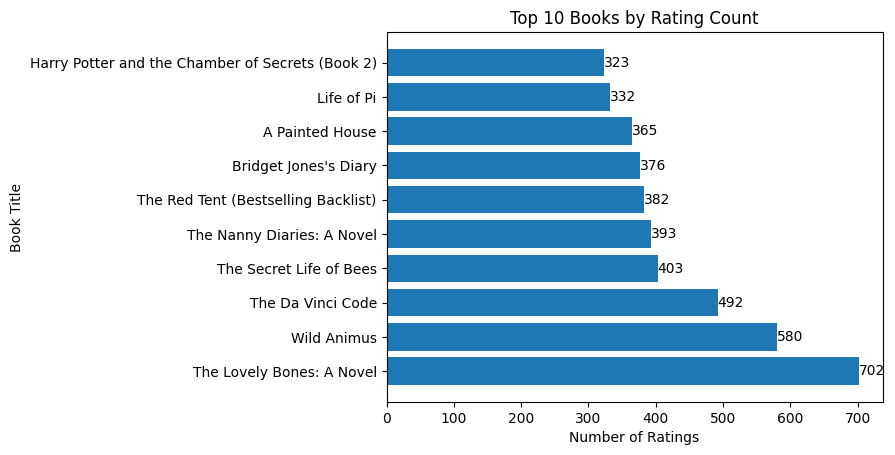

In [33]:


bars = plt.barh(top_ten['Book-Title'], top_ten['Rating_Count'])

# Add data labels
plt.bar_label(bars)

# Axis labels
plt.xlabel('Number of Ratings')
plt.ylabel('Book Title')

plt.title('Top 10 Books by Rating Count')

plt.show()

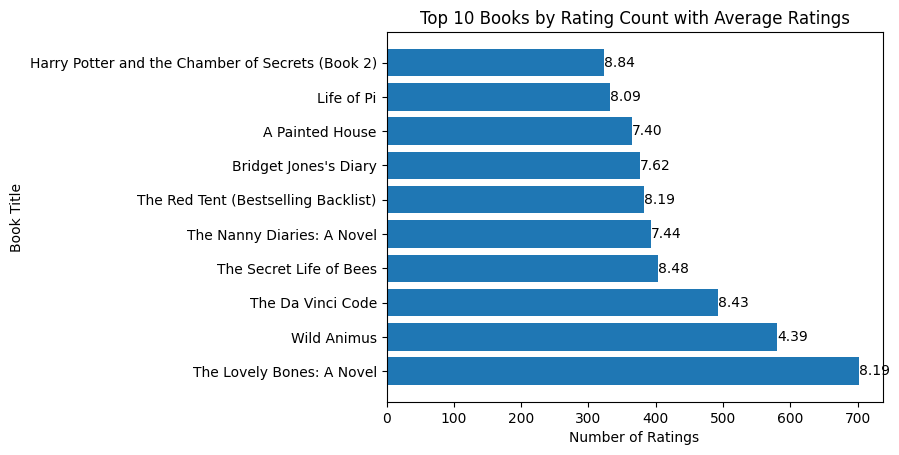

In [34]:
bars = plt.barh(top_ten['Book-Title'], top_ten['Rating_Count'])

plt.bar_label(bars, labels=[f'{x:.2f}' for x in top_ten['Average_Rating']])

plt.xlabel('Number of Ratings')
plt.ylabel('Book Title')
plt.title('Top 10 Books by Rating Count with Average Ratings')

plt.show()

# USER-USER Similarity

In [35]:
# Keep users with more than 20 rated books
active_user_mask = (pivot_table > 0).sum(axis=1) > 20
pivot_table = pivot_table.loc[active_user_mask]

# Keep books with more than 30 ratings
popular_book_mask = (pivot_table > 0).sum(axis=0) > 30
pivot_table = pivot_table.loc[:, popular_book_mask]

# To Reduce memory
pivot_table = pivot_table.astype('float32')
pivot_table

Book-Title,1984,1st to Die: A Novel,2nd Chance,A Bend in the Road,"A Child Called \It\"": One Child's Courage to Survive""",A Heartbreaking Work of Staggering Genius,A Is for Alibi (Kinsey Millhone Mysteries (Paperback)),A Map of the World,A Painted House,A Prayer for Owen Meany,...,When the Wind Blows,Where the Heart Is (Oprah's Book Club (Paperback)),While I Was Gone,Whispers,White Oleander : A Novel,White Oleander : A Novel (Oprah's Book Club),Wicked: The Life and Times of the Wicked Witch of the West,Wild Animus,"Wizard and Glass (The Dark Tower, Book 4)","\O\"" Is for Outlaw"""
User-ID,,,,,,,,,,,,,,,,,,,,,
254,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
638,0.0,0.0,9.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
882,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1131,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1424,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276231,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0
276680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
277427,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


I filtered active users and popular books to reduce noise and improve recommendation accuracy, because inactive users and rarely rated books doesnt provide meaningful patterns.

In [36]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd 

In [37]:
from scipy.sparse import csr_matrix
sparse_matrix = csr_matrix(pivot_table.values) 
# using sparse matrix, because we have many zeros in our pivot table, spare matrix onl stores non-zero values, which saves memory and speeds up calculations.

In [38]:
def recommend_user_user(user_id):

    if user_id not in pivot_table.index:
        return []

    user_pos = pivot_table.index.get_loc(user_id)
    target_vector = sparse_matrix[user_pos]

    similarity_scores = cosine_similarity(
        target_vector,
        sparse_matrix
    ).flatten()

    sim_df = pd.DataFrame({
        'User-ID': pivot_table.index,
        'Similarity': similarity_scores
    })

    sim_df = sim_df[sim_df['User-ID'] != user_id]

    sim_df = sim_df.sort_values(
        by='Similarity',
        ascending=False
    ).head(10)

    read_books = pivot_table.loc[user_id]
    read_books = read_books[read_books > 0].index.tolist()

    recommendations = {}

    for sim_user in sim_df['User-ID']:
        books = pivot_table.loc[sim_user]

        for book in books[books > 0].index:
            if book not in read_books:
                recommendations[book] = recommendations.get(book, 0) + 1

    top_books = sorted(
        recommendations.items(),
        key=lambda x: x[1],
        reverse=True
    )[:5]

    # RETURN LIST (NOT STRING)
    return [book[0] for book in top_books]

In [39]:
# Step 6: Run
user_id = int(input("Enter User-ID: "))
print("Recommendations for User-ID: " + str(user_id))
print("Recommendations:", recommend_user_user(user_id))

Recommendations for User-ID: 254
Recommendations: ['Harry Potter and the Order of the Phoenix (Book 5)', 'The Two Towers (The Lord of the Rings, Part 2)', 'Artemis Fowl (Artemis Fowl, Book 1)', 'The Reptile Room (A Series of Unfortunate Events, Book 2)', 'Black House']


# Item Item similarity

In [40]:
book_similarity = cosine_similarity(pivot_table.T)

book_similarity_df = pd.DataFrame(
    book_similarity,
    index=pivot_table.columns,
    columns=pivot_table.columns
)

In [41]:
def recommend_item_item(user_id, exclude_books=None):

    if exclude_books is None:
        exclude_books = []

    if user_id not in pivot_table.index:
        return []

    user_data = pivot_table.loc[user_id]

    top_books = user_data[user_data > 0].sort_values(
        ascending=False
    ).head(10).index.tolist()

    read_books = user_data[user_data > 0].index.tolist()

    recommendations = {}

    for book in top_books:

        similar_books = book_similarity_df[book].sort_values(
            ascending=False
        )[1:21]

        for sim_book, score in similar_books.items():

            if sim_book not in read_books and sim_book not in exclude_books:
                recommendations[sim_book] = (
                    recommendations.get(sim_book, 0) + score
                )

    final_books = sorted(
        recommendations.items(),
        key=lambda x: x[1],
        reverse=True
    )[:5]

    return [book[0] for book in final_books]

In [42]:
user_id = int(input("Enter User-ID: "))
user_books = recommend_user_user(user_id)
print("Recommendations for User-ID: " + str(user_id))
print(recommend_item_item(user_id,exclude_books=user_books))

Recommendations for User-ID: 254
["Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))", "Bridget Jones's Diary", 'The Return of the King (The Lord of the Rings, Part 3)', 'The Bad Beginning (A Series of Unfortunate Events, Book 1)', 'The Catcher in the Rye']


In [43]:
user_books = recommend_user_user(user_id)

item_books = recommend_item_item(
    user_id,
    exclude_books=user_books
)

print("User-User Recommendations:")
for i, b in enumerate(user_books, 1):
    print(f"{i}. {b}")

print("\nItem-Item Recommendations:")
for i, b in enumerate(item_books, 1):
    print(f"{i+5}. {b}")

User-User Recommendations:
1. Harry Potter and the Order of the Phoenix (Book 5)
2. The Two Towers (The Lord of the Rings, Part 2)
3. Artemis Fowl (Artemis Fowl, Book 1)
4. The Reptile Room (A Series of Unfortunate Events, Book 2)
5. Black House

Item-Item Recommendations:
6. Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))
7. Bridget Jones's Diary
8. The Return of the King (The Lord of the Rings, Part 3)
9. The Bad Beginning (A Series of Unfortunate Events, Book 1)
10. The Catcher in the Rye


In [44]:
user_id = int(input("Enter User-ID: "))
print("Recommendations for User-ID: " + str(user_id))
for i, b in enumerate(user_books, 1):
    print(f"{i}. {b}")
for i, b in enumerate(item_books, 1):
    print(f"{i+5}. {b}")


Recommendations for User-ID: 254
1. Harry Potter and the Order of the Phoenix (Book 5)
2. The Two Towers (The Lord of the Rings, Part 2)
3. Artemis Fowl (Artemis Fowl, Book 1)
4. The Reptile Room (A Series of Unfortunate Events, Book 2)
5. Black House
6. Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))
7. Bridget Jones's Diary
8. The Return of the King (The Lord of the Rings, Part 3)
9. The Bad Beginning (A Series of Unfortunate Events, Book 1)
10. The Catcher in the Rye


In [45]:
def books_to_table(book_list, category_name):

    rows = []

    for i, book in enumerate(book_list, start=1):

        temp = df_filtered[
            df_filtered['Book-Title'] == book
        ][['Book-Title', 'Book-Author', 'Image-URL-S']].drop_duplicates()

        if not temp.empty:
            row = temp.iloc[0]

            rows.append({
                "Category": category_name,
                
                "Book": row['Book-Title'],
                "Author": row['Book-Author'],
                "Image": row['Image-URL-S']
            })

    return pd.DataFrame(rows)

In [46]:
user_id = int(input("Enter User-ID: "))
print("Recommendations for User-ID:", user_id)

Recommendations for User-ID: 254


In [47]:
# Get Recommendations 
uu = recommend_user_user(user_id)
ii = recommend_item_item(user_id,exclude_books=uu)


#  Convert to Tables 
df1 = books_to_table(uu, "User-User")
df2 = books_to_table(ii, "Item-Item")


#  Final Table
final_table = pd.concat(
    [df1, df2],
    ignore_index=True
)

# Display
final_table

,Category,Book,Author,Image
0,User-User,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,http://images.amazon.com/images/P/043935806X.0...
1,User-User,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339711.0...
2,User-User,"Artemis Fowl (Artemis Fowl, Book 1)",Eoin Colfer,http://images.amazon.com/images/P/0786817070.0...
3,User-User,The Reptile Room (A Series of Unfortunate Even...,Lemony Snicket,http://images.amazon.com/images/P/0064407675.0...
4,User-User,Black House,Stephen King,http://images.amazon.com/images/P/0375504397.0...
5,Item-Item,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,http://images.amazon.com/images/P/059035342X.0...
6,Item-Item,Bridget Jones's Diary,Helen Fielding,http://images.amazon.com/images/P/0330332775.0...
7,Item-Item,"The Return of the King (The Lord of the Rings,...",J. R. R. Tolkien,http://images.amazon.com/images/P/0395272211.0...
8,Item-Item,The Bad Beginning (A Series of Unfortunate Eve...,Lemony Snicket,http://images.amazon.com/images/P/0064407667.0...
9,Item-Item,The Catcher in the Rye,J.D. Salinger,http://images.amazon.com/images/P/0316769487.0...


In [48]:
from IPython.display import display, HTML

final_table['Cover'] = final_table['Image'].apply(
    lambda x: f'<img src="{x}" width="80">'
)

display(
    
    HTML(
        final_table[
            ['Category', 'Book', 'Author', 'Cover']
        ].to_html(escape=False, index=False)
    )
)

Category,Book,Author,Cover
User-User,Harry Potter and the Order of the Phoenix (Book 5),J. K. Rowling,
User-User,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,
User-User,"Artemis Fowl (Artemis Fowl, Book 1)",Eoin Colfer,
User-User,"The Reptile Room (A Series of Unfortunate Events, Book 2)",Lemony Snicket,
User-User,Black House,Stephen King,
Item-Item,Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)),J. K. Rowling,
Item-Item,Bridget Jones's Diary,Helen Fielding,
Item-Item,"The Return of the King (The Lord of the Rings, Part 3)",J. R. R. Tolkien,
Item-Item,"The Bad Beginning (A Series of Unfortunate Events, Book 1)",Lemony Snicket,
Item-Item,The Catcher in the Rye,J.D. Salinger,
